In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import re

In [2]:
# load the dataset
file_path = "h224.dta"
df_raw = pd.read_stata(file_path, convert_dates=False, convert_categoricals=False)

In [3]:
df_raw.head() # fetching top 5 rows

,DUID,PID,DUPERSID,PANEL,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,...,RXOSR20,RXPTR20,RXOTH20,PERWT20F,FAMWT20F,FAMWT20C,SAQWT20F,DIABW20F,VARSTR,VARPSU
0,2320005,101,2320005101,23,A,A,A,A,A,A,...,0,0,0,8418.417067,10019.765809,10019.765809,0.000000,0.0,2079,1
1,2320005,102,2320005102,23,A,A,A,A,A,A,...,0,0,0,5199.931866,10019.765809,10019.765809,0.000000,0.0,2079,1
2,2320006,101,2320006101,23,A,A,A,A,A,A,...,0,0,0,2139.840017,1646.585855,1646.585855,0.000000,0.0,2028,1
3,2320006,102,2320006102,23,B,B,B,B,B,B,...,0,0,0,2216.008686,2883.001611,2883.001611,4082.830163,0.0,2028,1
4,2320006,103,2320006103,23,A,A,A,A,A,A,...,0,0,0,4157.285889,1646.585855,1646.585855,0.000000,0.0,2028,1


In [4]:
df_raw.shape

(27805, 1451)

In [5]:
# Dataset information
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27805 entries, 0 to 27804
Columns: 1451 entries, DUID to VARPSU
dtypes: float64(20), int16(378), int32(211), int8(827), object(15)
memory usage: 71.8+ MB


In [6]:
# Select MEPS H224 variables relevant to claim approval
cols = {
    'AGE42X':   'AGE',
    'SEX':      'SEX',
    'RACETHX':  'RACE',
    'POVCAT20': 'INCOME_PCT_FPL',
    'INSCOV20': 'INSURANCE_TYPE',
    'TOTEXP20': 'TOTAL_EXPENDITURE',
    'EMPST42':  'EMPLOYED',
    'EDUCYR':   'EDUCATION',
    'REGION20': 'REGION',
    'OBTOTV20': 'NUM_CHRONIC',    # proxy: total office visits
}

df = df_raw[list(cols.keys())].rename(columns=cols)
print(df.shape)
print(df.isnull().sum())

(27805, 10)
AGE                  0
SEX                  0
RACE                 0
INCOME_PCT_FPL       0
INSURANCE_TYPE       0
TOTAL_EXPENDITURE    0
EMPLOYED             0
EDUCATION            0
REGION               0
NUM_CHRONIC          0
dtype: int64


In [7]:
# OBTOTV20 = total office-based visits (healthcare utilisation proxy)
cols = {
    'AGE42X':   'AGE',
    'SEX':      'SEX',
    'RACETHX':  'RACE',
    'POVCAT20': 'INCOME_PCT_FPL',
    'INSCOV20': 'INSURANCE_TYPE',
    'TOTEXP20': 'TOTAL_EXPENDITURE',
    'EMPST42':  'EMPLOYED',
    'EDUCYR':   'EDUCATION',
    'REGION20': 'REGION',
    'OBTOTV20': 'NUM_VISITS',   # ← correct column name (was 'NUM_CHRONIC' before — bug fixed)
}

df = df_raw[list(cols.keys())].rename(columns=cols).copy()
print("Selected shape:", df.shape)
print(df.isnull().sum())

Selected shape: (27805, 10)
AGE                  0
SEX                  0
RACE                 0
INCOME_PCT_FPL       0
INSURANCE_TYPE       0
TOTAL_EXPENDITURE    0
EMPLOYED             0
EDUCATION            0
REGION               0
NUM_VISITS           0
dtype: int64


In [8]:
# MEPS uses negative codes:
# -1 = Inapplicable, -7 = Refused, -8 = Don't know, -9 = Not ascertained
# Replace all negative values with NaN
df = df.map(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# Drop rows missing more than 30% of features
df = df.dropna(thresh=int(0.7 * df.shape[1]))

# Impute remaining NaNs with column median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

missing_pct = df.isnull().mean().round(3) * 100
print("\nMissing % per column after imputation:")
print(missing_pct[missing_pct > 0] if missing_pct.sum() > 0 else "None")
print("\nClean shape:", df.shape)

Duplicates removed: 289

Missing % per column after imputation:
None

Clean shape: (27512, 10)


In [9]:
# CLAIM_APPROVED = 1 if person has insurance AND recorded positive expenditure
df['CLAIM_APPROVED'] = (
    (df['INSURANCE_TYPE'].isin([1, 2, 3])) &
    (df['TOTAL_EXPENDITURE'] > 0)
).astype(int)

print("Approval rate:", df['CLAIM_APPROVED'].mean().round(3))
print(df['CLAIM_APPROVED'].value_counts())

Approval rate: 0.833
CLAIM_APPROVED
1    22911
0     4601
Name: count, dtype: int64


# EDA

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

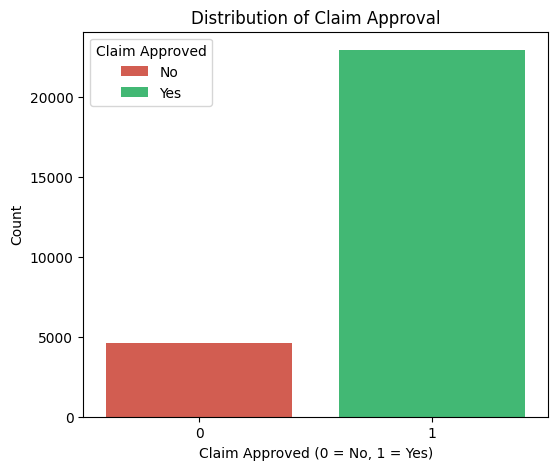

In [11]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='CLAIM_APPROVED',
    hue='CLAIM_APPROVED', # Assign x to hue to remove warning
    data=df,
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Distribution of Claim Approval')
plt.xlabel('Claim Approved (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
new_labels = ['No', 'Yes']
ax.legend(handles=handles, labels=new_labels, title='Claim Approved')

plt.show()

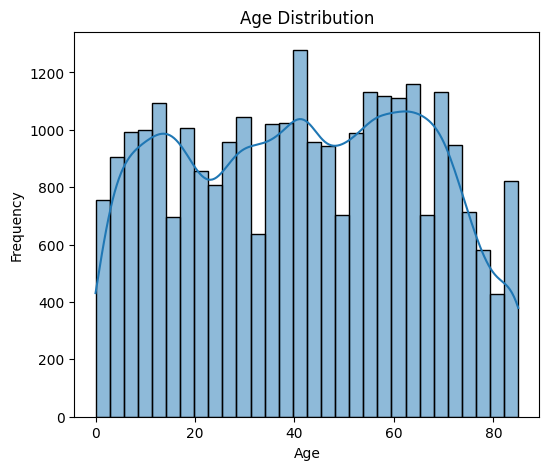

In [12]:
plt.figure(figsize=(6,5))

sns.histplot(
    df['AGE'].dropna(),
    bins=30,
    kde=True
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_5683/1655985970.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([insurance_labels.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()])


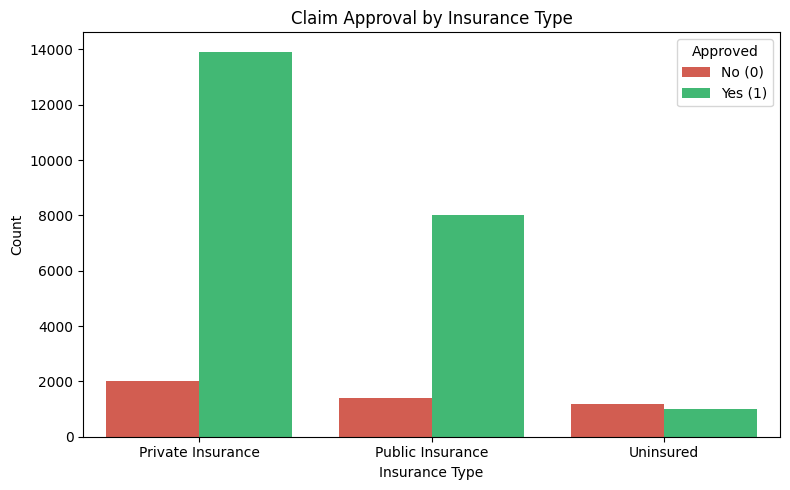

In [13]:

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x='INSURANCE_TYPE',
    hue='CLAIM_APPROVED',
    data=df,
    palette=['#e74c3c', '#2ecc71']
)

# Add labels for insurance types
insurance_labels = {
    1: "Private Insurance",
    2: "Public Insurance",
    3: "Uninsured"
}

ax.set_xticklabels([insurance_labels.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()])

plt.title("Claim Approval by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Count")
plt.legend(title="Approved", labels=["No (0)", "Yes (1)"])

plt.tight_layout()
plt.show()

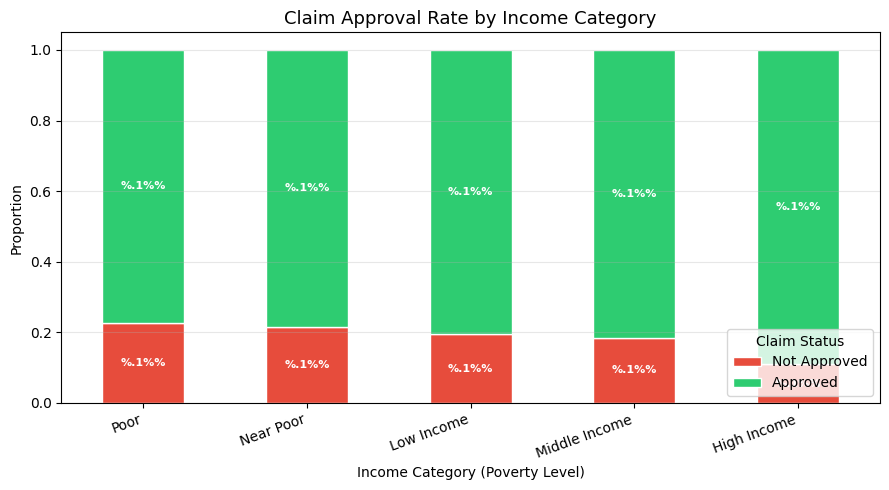

In [14]:
# Approval rate broken down by income poverty category
# INCOME_PCT_FPL: 1=Poor, 2=Near Poor, 3=Low Income, 4=Middle Income, 5=High Income

income_labels = {1: 'Poor', 2: 'Near Poor', 3: 'Low Income', 4: 'Middle Income', 5: 'High Income'}
df['INCOME_LABEL'] = df['INCOME_PCT_FPL'].map(income_labels)

income_approval = (
    df.groupby('INCOME_LABEL')['CLAIM_APPROVED']
    .value_counts(normalize=True)
    .unstack()
    .reindex(['Poor', 'Near Poor', 'Low Income', 'Middle Income', 'High Income'])
)

fig, ax = plt.subplots(figsize=(9, 5))
income_approval.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c', '#2ecc71'], edgecolor='white'
)

ax.set_title('Claim Approval Rate by Income Category', fontsize=13)
ax.set_xlabel('Income Category (Poverty Level)')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(['Not Approved', 'Approved'], title='Claim Status', loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on each bar segment
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.1%%', label_type='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Log-transform expenditure to reduce right skew
df['LOG_EXPENDITURE'] = np.log1p(df['TOTAL_EXPENDITURE'])

# Bin age into 5 groups: 0-30, 30-45, 45-60, 60-75, 75+
df['AGE_GROUP'] = pd.cut(
    df['AGE'], bins=[0, 30, 45, 60, 75, 100],
    labels=[1, 2, 3, 4, 5]
).astype(float)

# High utiliser: office visits above median
median_visits = df['NUM_VISITS'].median()
df['HIGH_UTILIZER'] = (df['NUM_VISITS'] > median_visits).astype(int)

# Interaction feature: insured AND employed (most stable coverage group)
df['INSURED_EMPLOYED'] = (
    (df['INSURANCE_TYPE'].isin([1, 2])) & (df['EMPLOYED'] == 1)
).astype(int)

# Drop original expenditure (replaced by log version)
df.drop(columns=['TOTAL_EXPENDITURE'], inplace=True)

print("Features after engineering:", df.shape[1])
print(df.head(3))

Features after engineering: 15
    AGE  SEX  RACE  INCOME_PCT_FPL  INSURANCE_TYPE  EMPLOYED  EDUCATION  \
0  73.0    2     2               2               2       4.0       14.0   
1  84.0    1     2               2               2       4.0       12.0   
2  46.0    2     1               3               3       4.0       12.0   

   REGION  NUM_VISITS  CLAIM_APPROVED INCOME_LABEL  LOG_EXPENDITURE  \
0     1.0           4               1    Near Poor         6.131226   
1     1.0           0               1    Near Poor         6.336826   
2     3.0           1               1   Low Income         4.948760   

   AGE_GROUP  HIGH_UTILIZER  INSURED_EMPLOYED  
0        4.0              1                 0  
1        5.0              0                 0  
2        3.0              0                 0  


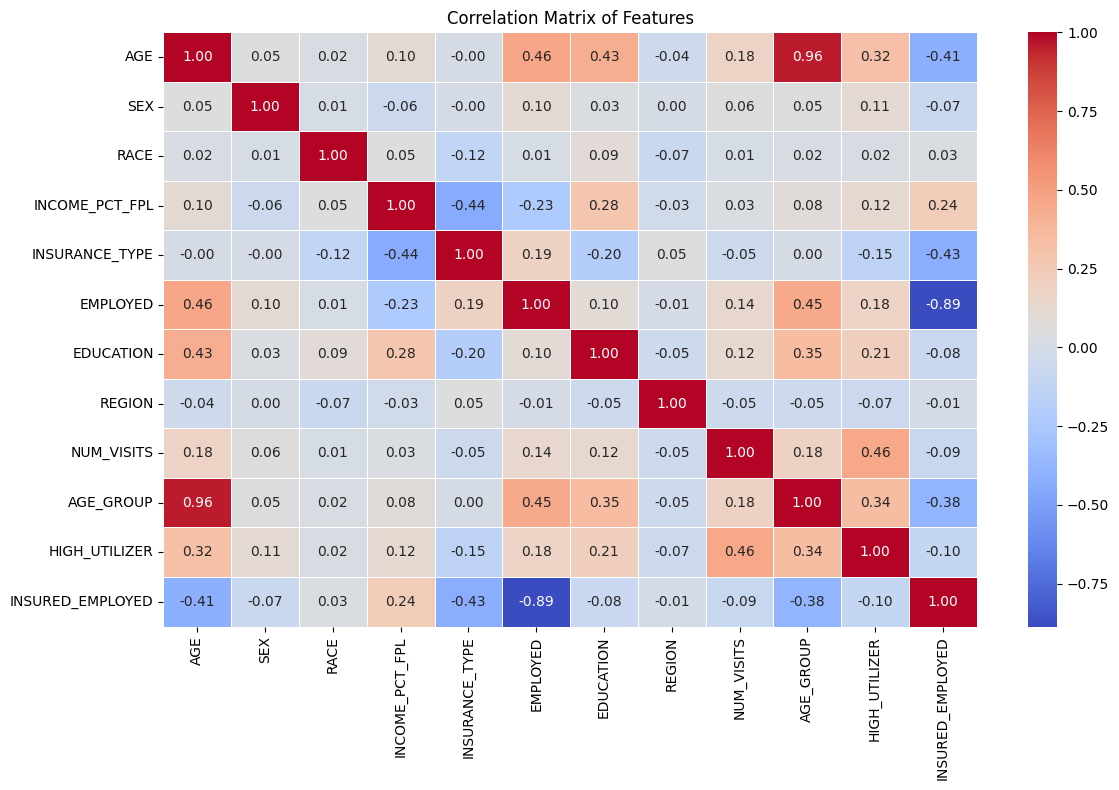

In [18]:
# Drop leakage columns (payment/expenditure/charge codes)
leakage_pattern = re.compile(r'(EXP|PAY|CHG|CHARGE|PMT|PRPAY|MCDPAY|PRVPAY)', re.IGNORECASE)

# Drop ID-like columns
id_pattern = re.compile(r'^(DUID|PID|DUPERSID|CPSFAMID)$|FAMID', re.IGNORECASE)

drop_cols = set()
for col in df.columns:
    if col == 'CLAIM_APPROVED':
        continue
    if leakage_pattern.search(col) or id_pattern.search(col):
        drop_cols.add(col)

X = df.drop(columns=list(drop_cols) + ['CLAIM_APPROVED'], errors='ignore')
X = X.select_dtypes(include='number')   # keep numeric columns only

# Select only numerical features
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

In [19]:
# Drop leakage columns (payment/expenditure/charge codes)
leakage_pattern = re.compile(r'(EXP|PAY|CHG|CHARGE|PMT|PRPAY|MCDPAY|PRVPAY)', re.IGNORECASE)

# Drop ID-like columns
id_pattern = re.compile(r'^(DUID|PID|DUPERSID|CPSFAMID)$|FAMID', re.IGNORECASE)

drop_cols = set()
for col in df.columns:
    if col == 'CLAIM_APPROVED':
        continue
    if leakage_pattern.search(col) or id_pattern.search(col):
        drop_cols.add(col)

print(f"Dropping {len(drop_cols)} leakage/ID columns: {sorted(drop_cols)}")

X = df.drop(columns=list(drop_cols) + ['CLAIM_APPROVED'], errors='ignore')
X = X.select_dtypes(include='number')   # keep numeric columns only
y = df['CLAIM_APPROVED']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Dropping 1 leakage/ID columns: ['LOG_EXPENDITURE']
X shape: (27512, 12)
y distribution:
 CLAIM_APPROVED
1    22911
0     4601
Name: count, dtype: int64


# Train/Test

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=90, stratify=y
)
print("Train size:", X_train.shape, "  Test size:", X_test.shape)

Train size: (19258, 12)   Test size: (8254, 12)


In [21]:
results = []

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    pred  = pipeline.predict(X_te)
    proba = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    acc  = accuracy_score(y_te, pred)
    auc  = roc_auc_score(y_te, proba) if proba is not None else np.nan
    report = classification_report(y_te, pred, output_dict=True)
    f1   = report['weighted avg']['f1-score']
    prec = report['weighted avg']['precision']
    rec  = report['weighted avg']['recall']

    results.append({'Model': name, 'Accuracy': acc, 'AUC-ROC': auc,
                    'F1 (weighted)': f1, 'Precision': prec, 'Recall': rec})
    print(f"  {name} : ")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}" if not np.isnan(auc) else "  AUC-ROC  : N/A")
    print(f"  F1 (wtd) : {f1:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_te, pred))
    return pipeline, pred, proba

In [22]:

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# SVM

In [23]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=90))
])

svm_pipe, svm_pred, svm_proba = evaluate_model(
    'SVM (RBF)', svm_pipe, X_train, y_train, X_test, y_test
)


  SVM (RBF) : 
  Accuracy : 0.8470
  AUC-ROC  : 0.9184
  F1 (wtd) : 0.8206

  Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.26      0.36      1380
           1       0.87      0.97      0.91      6874

    accuracy                           0.85      8254
   macro avg       0.73      0.61      0.64      8254
weighted avg       0.82      0.85      0.82      8254



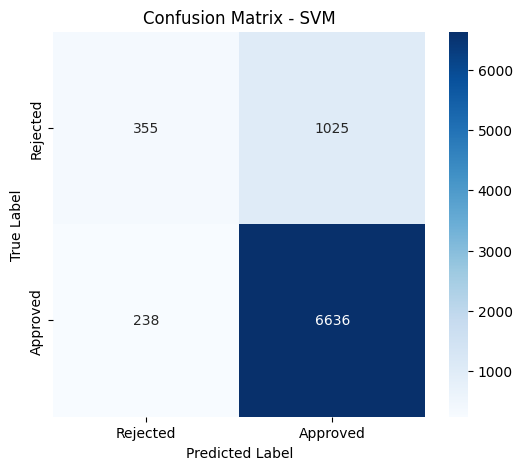

In [24]:
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Gradient Boosting

In [25]:
gb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                           max_depth=4, random_state=42))
])
gb_pipe, gb_pred, gb_proba = evaluate_model(
    'Gradient Boosting', gb_pipe, X_train, y_train, X_test, y_test
)

  Gradient Boosting : 
  Accuracy : 0.8868
  AUC-ROC  : 0.9439
  F1 (wtd) : 0.8886

  Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67      1380
           1       0.94      0.92      0.93      6874

    accuracy                           0.89      8254
   macro avg       0.79      0.81      0.80      8254
weighted avg       0.89      0.89      0.89      8254



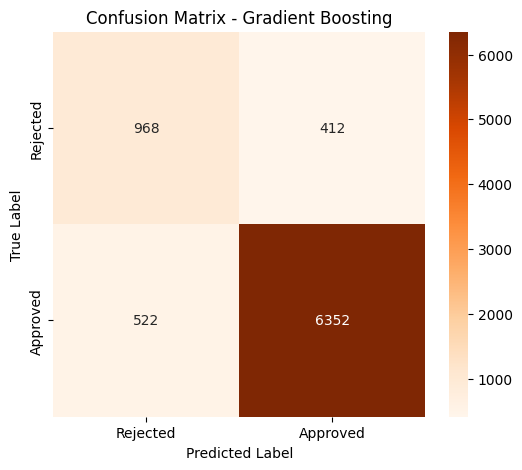

In [26]:
cm_gb = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Deep Neural Network

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Create a pipeline with SimpleImputer, StandardScaler and the Keras model
k_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Added imputer
    ('scaler', StandardScaler()),
    ('mlp', Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ]))
])

# Compile the Keras model within the pipeline
k_pipeline.named_steps['mlp'].compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = k_pipeline.fit(
    X_train,
    y_train,
    mlp__epochs=30,
    mlp__batch_size=32,
    mlp__validation_split=0.1
)

Epoch 1/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8389 - loss: 0.3392 - val_accuracy: 0.8577 - val_loss: 0.3057
Epoch 2/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8429 - loss: 0.3161 - val_accuracy: 0.8577 - val_loss: 0.2955
Epoch 3/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8474 - loss: 0.3062 - val_accuracy: 0.8603 - val_loss: 0.2818
Epoch 4/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8499 - loss: 0.2980 - val_accuracy: 0.8603 - val_loss: 0.2698
Epoch 5/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8543 - loss: 0.2798 - val_accuracy: 0.8676 - val_loss: 0.2476
Epoch 6/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8594 - loss: 0.2571 - val_accuracy: 0.8769 - val_loss: 0.2256
Epoch 7/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss: 0.2384 - val_accuracy: 0.8847 - val_loss: 0.2026
Epoch 8/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8694 - loss: 0.2271 - val_accuracy: 0.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [29]:
# Transform X_test using imputer and scaler
X_test_imputed = k_pipeline.named_steps['imputer'].transform(X_test)
X_test_scaled = k_pipeline.named_steps['scaler'].transform(X_test_imputed)

# Predicted probabilities from neural network
nn_proba = k_pipeline.named_steps['mlp'].predict(X_test_scaled).ravel()

# Convert probabilities to class labels
nn_pred = (nn_proba > 0.5).astype(int)

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [30]:
results = []

models_data = {
    'SVM': (svm_pred, svm_proba),
    'Gradient Boosting': (gb_pred, gb_proba),
    'Neural Network': (nn_pred, nn_proba)
}

for model_name, (y_pred, y_proba) in models_data.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print(results_df)

               Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0     Neural Network  0.883935   0.887952  0.883935  0.885722  0.943974
1  Gradient Boosting  0.886843   0.890700  0.886843  0.888555  0.943919
2                SVM  0.846983   0.821473  0.846983  0.820608  0.918395


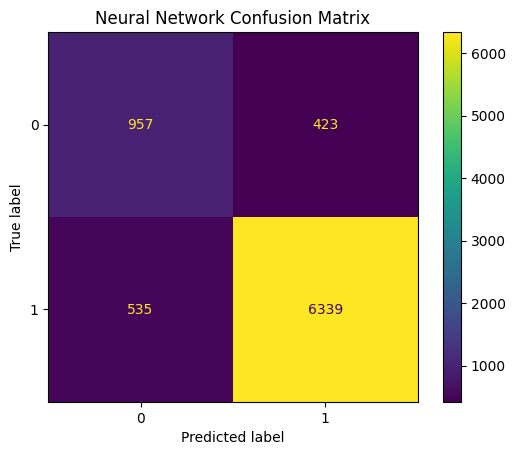

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use nn_pred for the Neural Network's predictions
cm = confusion_matrix(y_test, nn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Neural Network Confusion Matrix")
plt.show()

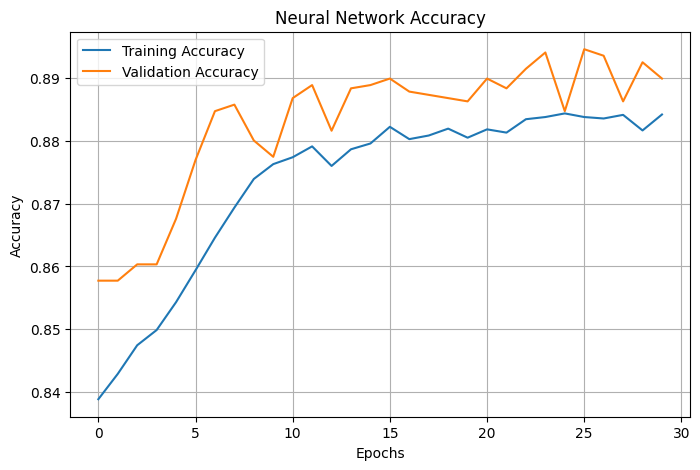

In [32]:
import matplotlib.pyplot as plt

# Extract history from the pipeline
history = k_pipeline.named_steps['mlp'].history

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Neural Network Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

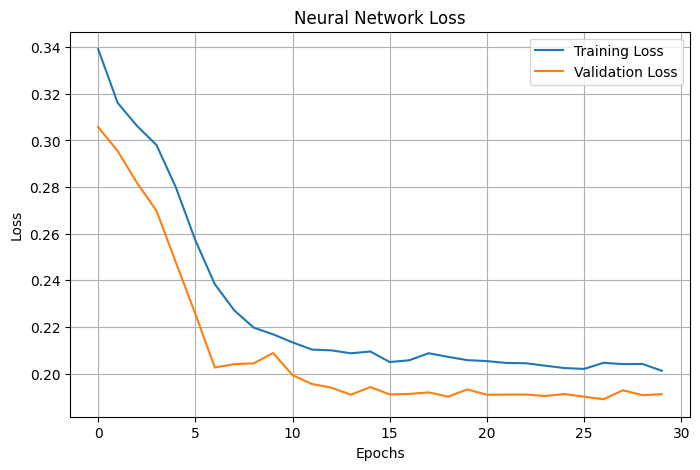

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Neural Network Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Model Comparision

In [34]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df = results_df.round(4)

print("\nModel Comparison")
print(results_df.to_string(index=False))


Model Comparison
            Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
   Neural Network    0.8839     0.8880  0.8839    0.8857   0.9440
Gradient Boosting    0.8868     0.8907  0.8868    0.8886   0.9439
              SVM    0.8470     0.8215  0.8470    0.8206   0.9184


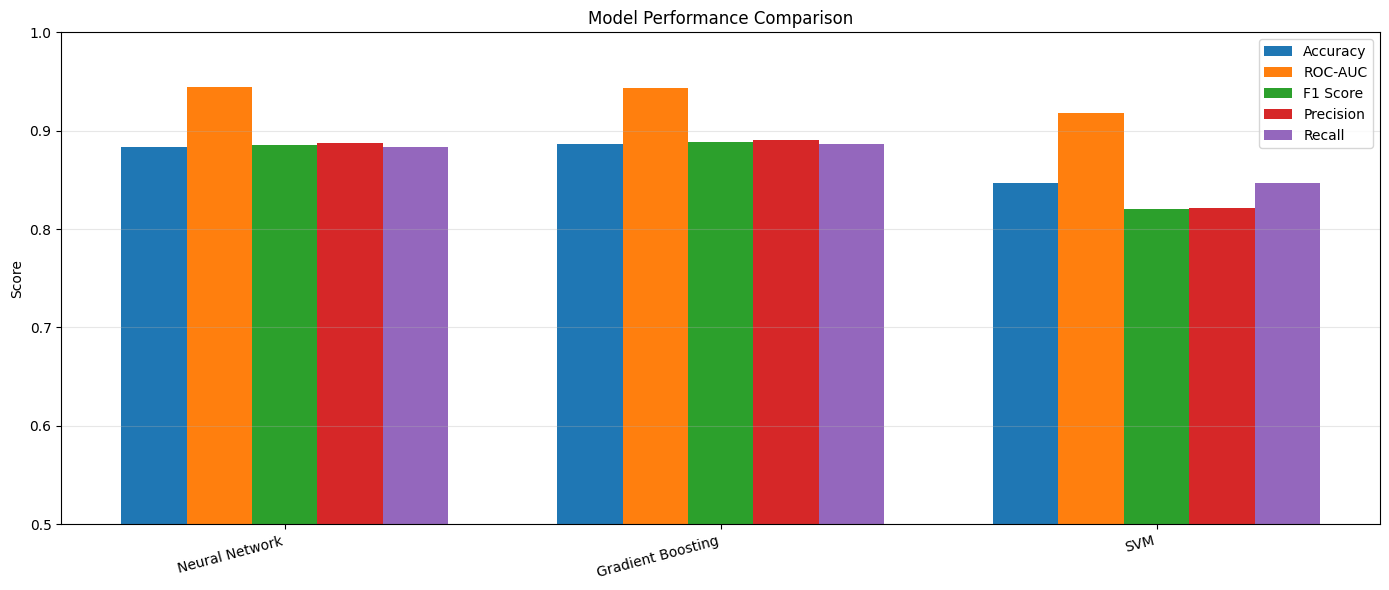

In [35]:
metrics = ['Accuracy', 'ROC-AUC', 'F1 Score', 'Precision', 'Recall'] # Corrected 'F1 (weighted)' to 'F1 Score'
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ROC Curve

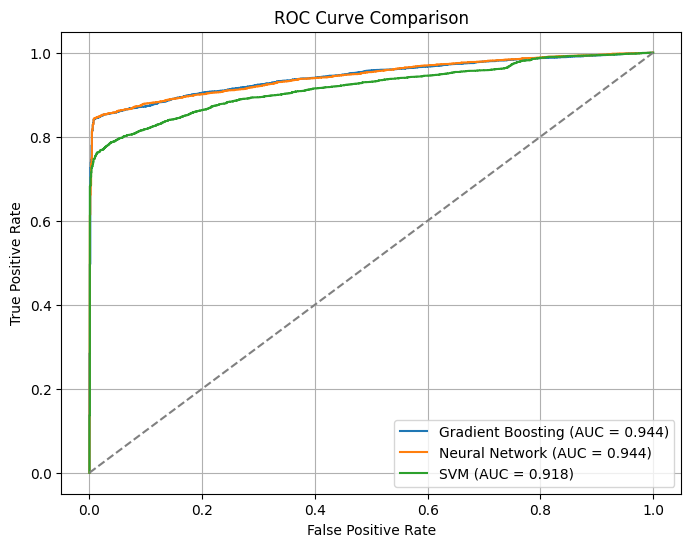

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)
auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_proba)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.3f})')

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')

# Random line
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

# Features importance

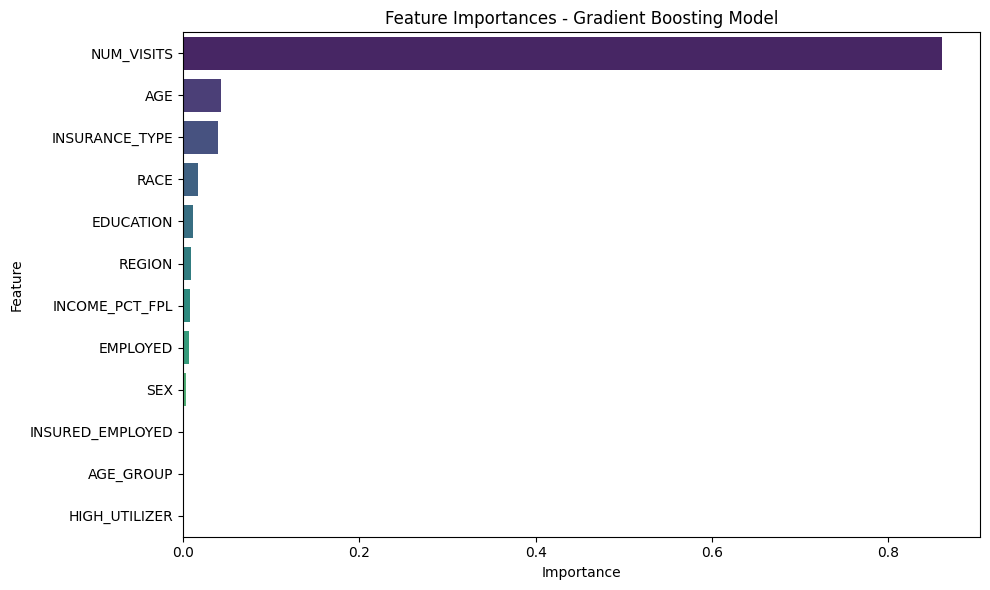

In [37]:

gb_model = gb_pipe.named_steps['model']

feat_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False) # Add hue and legend=False to resolve FutureWarning
plt.title('Feature Importances - Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Actual Vs Predicted

In [38]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': nn_pred,
    'Prob_Approved': nn_proba.round(4),
    'Correct': (y_test.values == nn_pred)
}).reset_index(drop=True)

print("Sample of Actual vs. Predicted Values (Neural Network):")
display(comparison_df.head(10))

Sample of Actual vs. Predicted Values (Neural Network):


,Actual,Predicted,Prob_Approved,Correct
0,1,1,1.0000,True
1,0,1,0.5799,False
2,1,1,1.0000,True
3,1,0,0.3979,False
4,0,0,0.3318,True
5,0,0,0.3712,True
6,1,1,1.0000,True
7,1,1,0.9998,True
8,1,1,1.0000,True
9,1,1,0.9871,True
